In [1]:
# ============================================================
# Shared-Rz / fixed-Rx(pi) feed-forward Toric-code DPQC
# Reduced-state SLD-QFIM + QFIM-rank analysis
#
# Design:
#   - q0,q1,q2,q3 : four Toric-code system qubits
#   - q4          : persistent center ancilla
#   - fresh ancilla is appended in each layer and traced out
#
# Each unitary layer:
#   4 x [Rz(q0) Rz(q1) Rxx(q0,q1)]
#
# Feed-forward:
#   CNOT(center -> fresh)
#   controlled-[Rz(varphi) Rx(pi) Rz(varphi)]
#        fresh = control
#        center = target
#
# Feed-forward parameter rule:
#   varphi is trainable and shared by every layer.
#   Rx is fixed to pi in every layer.
#   Rz(varphi) Rx(pi) Rz(varphi) = Rx(pi), so varphi is
#   retained as a nominal but exactly redundant parameter.
#   Unitary parameters remain layer-specific.
#
# Nominal parameter count: P(L) = 12 L + 1.
#
# QFIM rank:
#   number of QFIM eigenvalues >= 1e-12
# ============================================================

from __future__ import annotations

from dataclasses import dataclass
from functools import reduce
from pathlib import Path
from time import sleep
from typing import Iterable, Optional
from uuid import uuid4

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import jax
jax.config.update("jax_enable_x64", True)

import jax.numpy as jnp

from qiskit import QuantumCircuit
from qiskit.circuit import Parameter


# ============================================================
# 1. Basic configuration
# ============================================================

REAL_DTYPE = jnp.float64
COMPLEX_DTYPE = jnp.complex128

# Four physical Toric-code system qubits + one persistent center ancilla
NUM_OUTER_SYSTEM_QUBITS = 4
NUM_KEPT_QUBITS = 5

TOP = 0
LEFT = 1
RIGHT = 2
BOTTOM = 3
ANC_CENTER = 4

# In the temporary 6-qubit density matrix
FRESH_ANCILLA = 5

# Same connectivity as the attached Toric-code DPQC
LAYER_PAIRS = (
    (LEFT, BOTTOM),
    (RIGHT, BOTTOM),
    (TOP, RIGHT),
    (TOP, ANC_CENTER),
)

NUM_BLOCKS = len(LAYER_PAIRS)
PARAMS_PER_BLOCK = 3

# 4 blocks x 3 parameters = 12
NUM_UNITARY_PARAMS_PER_LAYER = NUM_BLOCKS * PARAMS_PER_BLOCK

# One nominal trainable Rz angle shared by all layers.
NUM_TRAINABLE_FEED_FORWARD_PARAMS = 1
TRAINABLE_FEED_FORWARD_PARAMETER_NAMES = (
    "FF_shared_Rz",
)

# Rx is fixed; the symmetric shared Rz pair cancels exactly at pi.
FIXED_FF_RX_ANGLE = np.pi
SHARED_RZ_EXACTLY_REDUNDANT = True

# Rank definition requested by the user
QFIM_RANK_THRESHOLD = 1.0e-12

# Four-mode fermionic-Gaussian states are specified by an
# 8 x 8 real antisymmetric covariance matrix: 8*7/2 = 28.
FERMIONIC_GAUSSIAN_QFIM_RANK_BOUND = 28

# Small denominator cutoff in SLD-QFIM
SLD_EIG_SUM_EPS = 1.0e-12

# JVP block size for one-point calculations
DEFAULT_JVP_CHUNK = 16

# Random parameter points compiled and evaluated together
DEFAULT_SAMPLE_BATCH_SIZE = 4


# ============================================================
# 2. Pauli matrices and basic operators
# ============================================================

I2 = jnp.eye(2, dtype=COMPLEX_DTYPE)

X2 = jnp.array(
    [
        [0.0, 1.0],
        [1.0, 0.0],
    ],
    dtype=COMPLEX_DTYPE,
)

Y2 = jnp.array(
    [
        [0.0, -1.0j],
        [1.0j, 0.0],
    ],
    dtype=COMPLEX_DTYPE,
)

Z2 = jnp.array(
    [
        [1.0, 0.0],
        [0.0, -1.0],
    ],
    dtype=COMPLEX_DTYPE,
)

P0 = jnp.array(
    [
        [1.0, 0.0],
        [0.0, 0.0],
    ],
    dtype=COMPLEX_DTYPE,
)

P1 = jnp.array(
    [
        [0.0, 0.0],
        [0.0, 1.0],
    ],
    dtype=COMPLEX_DTYPE,
)


def _kron_all(matrices):
    return reduce(jnp.kron, matrices)


def ket0_density(dtype=COMPLEX_DTYPE):
    ket0 = jnp.array([1.0, 0.0], dtype=dtype)
    return jnp.outer(ket0, jnp.conjugate(ket0))


def rho_zero_state(n_qubits: int):
    return _kron_all(
        [ket0_density(COMPLEX_DTYPE)] * n_qubits
    )


def hermitian(matrix):
    return 0.5 * (
        matrix + jnp.conjugate(matrix.T)
    )


# ============================================================
# 3. Elementary gates
# ============================================================

def U_rz(theta):
    theta = jnp.asarray(theta, dtype=REAL_DTYPE)

    return jnp.array(
        [
            [jnp.exp(-0.5j * theta), 0.0],
            [0.0, jnp.exp(0.5j * theta)],
        ],
        dtype=COMPLEX_DTYPE,
    )


def U_rx(theta):
    theta = jnp.asarray(theta, dtype=REAL_DTYPE)

    c = jnp.cos(0.5 * theta)
    s = jnp.sin(0.5 * theta)

    return jnp.array(
        [
            [c, -1.0j * s],
            [-1.0j * s, c],
        ],
        dtype=COMPLEX_DTYPE,
    )


def U_rxx(theta):
    theta = jnp.asarray(theta, dtype=REAL_DTYPE)

    c = jnp.cos(0.5 * theta)
    s = jnp.sin(0.5 * theta)

    return (
        c * jnp.eye(4, dtype=COMPLEX_DTYPE)
        - 1.0j * s * jnp.kron(X2, X2)
    )


# CNOT:
# wire order = (control, target)
U_CX = jnp.array(
    [
        [1.0, 0.0, 0.0, 0.0],
        [0.0, 1.0, 0.0, 0.0],
        [0.0, 0.0, 0.0, 1.0],
        [0.0, 0.0, 1.0, 0.0],
    ],
    dtype=COMPLEX_DTYPE,
)


def controlled_single_qubit_unitary(
    U,
    *,
    control_pos: int,
    target_pos: int,
):
    """
    Two-qubit controlled-U matrix.

    The two local positions are 0 and 1.

    Example:
        wires = (center, fresh)
        control_pos = 1
        target_pos = 0

    means:
        fresh controls U acting on center.
    """

    if (control_pos, target_pos) == (0, 1):
        return (
            jnp.kron(P0, I2)
            + jnp.kron(P1, U)
        )

    if (control_pos, target_pos) == (1, 0):
        return (
            jnp.kron(I2, P0)
            + jnp.kron(U, P1)
        )

    raise ValueError(
        "control_pos and target_pos must be "
        "different and belong to {0,1}."
    )


def U_crz(theta, *, control_pos, target_pos):
    return controlled_single_qubit_unitary(
        U_rz(theta),
        control_pos=control_pos,
        target_pos=target_pos,
    )


def U_crx(theta, *, control_pos, target_pos):
    return controlled_single_qubit_unitary(
        U_rx(theta),
        control_pos=control_pos,
        target_pos=target_pos,
    )


# ============================================================
# 4. Apply arbitrary local unitary to density matrix
# ============================================================

def apply_unitary_on_rho(
    rho,
    U,
    wires,
    n_qubits: int,
):
    """
    Apply U rho U^dagger on arbitrary wires.

    Parameters
    ----------
    rho:
        Density matrix of n_qubits.

    U:
        2^m x 2^m unitary.

    wires:
        Ordered tuple of m qubit indices.

    n_qubits:
        Total number of qubits.
    """

    wires = tuple(int(w) for w in wires)
    m = len(wires)

    if U.shape != (2**m, 2**m):
        raise ValueError(
            f"Expected U.shape={(2**m, 2**m)}, "
            f"got {U.shape}."
        )

    others = [
        i for i in range(n_qubits)
        if i not in wires
    ]

    perm = (
        list(wires)
        + others
        + [w + n_qubits for w in wires]
        + [o + n_qubits for o in others]
    )

    inv_perm = [0] * (2 * n_qubits)

    for i, axis in enumerate(perm):
        inv_perm[axis] = i

    rho_tensor = jnp.reshape(
        rho,
        (2,) * (2 * n_qubits),
    )

    rho_perm = jnp.transpose(
        rho_tensor,
        perm,
    )

    dim_local = 2**m
    dim_rest = 2 ** (n_qubits - m)

    rho_perm = jnp.reshape(
        rho_perm,
        (
            dim_local,
            dim_rest,
            dim_local,
            dim_rest,
        ),
    )

    # U rho
    rho_left = jnp.einsum(
        "ij,jrks->irks",
        U,
        rho_perm,
    )

    # U rho U^\dagger
    rho_both = jnp.einsum(
        "irps,bp->irbs",
        rho_left,
        jnp.conjugate(U),
    )

    rho_both = jnp.reshape(
        rho_both,
        (
            (2,) * m
            + (2,) * (n_qubits - m)
            + (2,) * m
            + (2,) * (n_qubits - m)
        ),
    )

    return jnp.reshape(
        jnp.transpose(
            rho_both,
            inv_perm,
        ),
        (2**n_qubits, 2**n_qubits),
    )


# ============================================================
# 5. Partial trace
# ============================================================

def append_fresh_ancilla_zero(rho):
    return jnp.kron(
        rho,
        ket0_density(dtype=rho.dtype),
    )


def partial_trace_last_qubit(
    rho,
    n_kept_qubits: int,
):
    """
    Trace out the last qubit from an
    (n_kept_qubits + 1)-qubit density matrix.
    """

    dim_kept = 2**n_kept_qubits

    rho_tensor = jnp.reshape(
        rho,
        (
            dim_kept,
            2,
            dim_kept,
            2,
        ),
    )

    return (
        rho_tensor[:, 0, :, 0]
        + rho_tensor[:, 1, :, 1]
    )


def partial_trace_one_qubit(
    rho,
    *,
    n_qubits: int,
    trace_wire: int,
):
    """
    Trace an arbitrary one-qubit subsystem.
    """

    keep_wires = [
        i for i in range(n_qubits)
        if i != trace_wire
    ]

    perm = (
        keep_wires
        + [trace_wire]
        + [i + n_qubits for i in keep_wires]
        + [trace_wire + n_qubits]
    )

    rho_tensor = jnp.reshape(
        rho,
        (2,) * (2 * n_qubits),
    )

    rho_perm = jnp.transpose(
        rho_tensor,
        perm,
    )

    dim_keep = 2 ** (n_qubits - 1)

    rho_perm = jnp.reshape(
        rho_perm,
        (
            dim_keep,
            2,
            dim_keep,
            2,
        ),
    )

    return (
        rho_perm[:, 0, :, 0]
        + rho_perm[:, 1, :, 1]
    )


# ============================================================
# 6. Shared-Rz / fixed-Rx(pi) feed-forward convention
# ============================================================

# Every layer uses the same nominal trainable FF_shared_Rz:
# Rz(FF_shared_Rz) Rx(pi) Rz(FF_shared_Rz).
# This product equals Rx(pi), so the shared direction is null.


# ============================================================
# 7. Parameter-space definition
# ============================================================

def num_trainable_parameters(
    n_layer: int,
):
    """
    12 layer-specific unitary parameters per layer
    + 1 shared feed-forward Rz parameter.
    Feed-forward Rx is fixed to pi.

    Nominal P(L) = 12 L + 1.
    """

    n_layer = int(n_layer)

    if n_layer < 1:
        raise ValueError(
            "n_layer must be >= 1."
        )

    return (
        NUM_UNITARY_PARAMS_PER_LAYER
        * n_layer
        + NUM_TRAINABLE_FEED_FORWARD_PARAMS
    )


def parameter_names(
    n_layer: int,
):
    """
    Return names in exactly the same order used by the
    numerical density-matrix circuit.

    Layer-specific unitary parameters come first, followed by
    the shared feed-forward Rz parameter. Rx(pi) is fixed.
    """

    n_layer = int(n_layer)

    if n_layer < 1:
        raise ValueError(
            "n_layer must be >= 1."
        )

    names = []

    for ell in range(
        1,
        n_layer + 1,
    ):

        for block_idx in range(
            NUM_BLOCKS
        ):
            names.extend(
                [
                    f"L{ell}_B{block_idx}_Rz_q0",
                    f"L{ell}_B{block_idx}_Rz_q1",
                    f"L{ell}_B{block_idx}_Rxx",
                ]
            )

    names.extend(
        TRAINABLE_FEED_FORWARD_PARAMETER_NAMES
    )

    return tuple(names)


def random_parameter_point(
    n_layer: int,
    *,
    seed: int = 0,
    low: float = 0.0,
    high: float = 2.0 * np.pi,
):
    """
    Random point from the shared-Rz parameter space.

    Every trainable angle is sampled independently
    and uniformly from [0, 2 pi).
    """

    n_params = num_trainable_parameters(
        n_layer
    )

    rng = np.random.default_rng(
        seed
    )

    theta = rng.uniform(
        low=low,
        high=high,
        size=n_params,
    )

    return jnp.asarray(
        theta,
        dtype=REAL_DTYPE,
    )


# 8. One unitary block
# ============================================================

def apply_unitary_block(
    rho,
    q0: int,
    q1: int,
    rz0,
    rz1,
    rxx_angle,
):
    rho = apply_unitary_on_rho(
        rho,
        U_rz(rz0),
        (q0,),
        NUM_KEPT_QUBITS,
    )

    rho = apply_unitary_on_rho(
        rho,
        U_rz(rz1),
        (q1,),
        NUM_KEPT_QUBITS,
    )

    rho = apply_unitary_on_rho(
        rho,
        U_rxx(rxx_angle),
        (q0, q1),
        NUM_KEPT_QUBITS,
    )

    return rho


# ============================================================
# 9. Feed-forward channel
# ============================================================

def apply_feed_forward(
    rho5,
    *,
    ff_rz_angle,
):
    """
    Implements:

        center --control----------Rz--Rx(pi)--Rz--
                 |                 ^    ^      ^
        fresh  --X-----------------control------------

    More precisely:
        1. append fresh |0>
        2. CNOT(center -> fresh)
        3. controlled Rz(ff_rz_angle) on center
        4. controlled Rx(pi) on center
        5. controlled Rz(ff_rz_angle) on center
        6. trace out fresh

    The same nominal trainable ff_rz_angle is reused in every
    layer. Since Rz(phi) Rx(pi) Rz(phi) = Rx(pi), its derivative
    is exactly zero and the physical channel remains a reset.
    """

    # Keep the nominal API/parameter while applying the exact
    # algebraic simplification Rz(phi) Rx(pi) Rz(phi) = Rx(pi).
    # This makes the shared QFIM direction exactly zero.
    _ = ff_rz_angle

    rho6 = append_fresh_ancilla_zero(
        rho5
    )

    # CNOT:
    # center = control
    # fresh  = target
    rho6 = apply_unitary_on_rho(
        rho6,
        U_CX,
        (
            ANC_CENTER,
            FRESH_ANCILLA,
        ),
        6,
    )

    # fresh controls the algebraically equivalent Rx(pi)
    rho6 = apply_unitary_on_rho(
        rho6,
        U_crx(
            FIXED_FF_RX_ANGLE,
            control_pos=1,
            target_pos=0,
        ),
        (
            ANC_CENTER,
            FRESH_ANCILLA,
        ),
        6,
    )

    # Trace out fresh ancilla.
    rho5_next = partial_trace_last_qubit(
        rho6,
        n_kept_qubits=NUM_KEPT_QUBITS,
    )

    return hermitian(
        rho5_next
    )


# ============================================================
# 10. Full DPQC density matrix
# ============================================================

RHO5_INITIAL = rho_zero_state(
    NUM_KEPT_QUBITS
)


def rho5_shared_rz_fixed_rx_pi_dpqc(
    theta,
    *,
    n_layer: int,
):
    """
    Five-qubit kept state q0,...,q4.

    Each layer has independent unitary parameters.
    Feed-forward uses the same nominal trainable Rz angle
    around fixed Rx(pi) in every layer. The Rz pair cancels.
    A fresh ancilla is inserted and traced out after each layer.
    """

    n_layer = int(n_layer)

    expected = num_trainable_parameters(
        n_layer
    )

    if (
        theta.ndim != 1
        or theta.shape[0] != expected
    ):
        raise ValueError(
            f"Expected theta.shape=({expected},), "
            f"got {theta.shape}."
        )

    num_unitary_parameters = (
        NUM_UNITARY_PARAMS_PER_LAYER
        * n_layer
    )

    ff_rz_angle = theta[
        num_unitary_parameters
    ]

    rho = RHO5_INITIAL
    parameter_index = 0

    for _ell in range(
        1,
        n_layer + 1,
    ):

        for q0, q1 in LAYER_PAIRS:

            rz0 = theta[
                parameter_index
            ]

            rz1 = theta[
                parameter_index + 1
            ]

            rxx_angle = theta[
                parameter_index + 2
            ]

            parameter_index += 3

            rho = apply_unitary_block(
                rho,
                q0,
                q1,
                rz0,
                rz1,
                rxx_angle,
            )

        rho = apply_feed_forward(
            rho,
            ff_rz_angle=ff_rz_angle,
        )

    if (
        parameter_index
        != num_unitary_parameters
    ):
        raise RuntimeError(
            "Internal parameter indexing error."
        )

    return hermitian(rho)


def rho4_shared_rz_fixed_rx_pi_dpqc(
    theta,
    *,
    n_layer: int,
):
    """
    Final reduced state rho_{0123}.

    q4 = persistent center ancilla is traced out.
    """

    rho5 = rho5_shared_rz_fixed_rx_pi_dpqc(
        theta,
        n_layer=n_layer,
    )

    rho4 = partial_trace_one_qubit(
        rho5,
        n_qubits=NUM_KEPT_QUBITS,
        trace_wire=ANC_CENTER,
    )

    return hermitian(
        rho4
    )


def make_rho4_fn(
    n_layer: int,
):
    """
    Create rho(theta) for a fixed circuit depth.
    """

    n_layer = int(n_layer)

    # Validate depth before creating the jitted closure.
    num_trainable_parameters(
        n_layer
    )

    def rho_fn(theta):
        return rho4_shared_rz_fixed_rx_pi_dpqc(
            theta,
            n_layer=n_layer,
        )

    return jax.jit(rho_fn)


# 11. Mixed-state SLD-QFIM
# ============================================================

def mixed_state_sld_qfim(
    theta,
    rho_fn,
    *,
    eig_sum_eps: float = SLD_EIG_SUM_EPS,
    jvp_chunk: int = DEFAULT_JVP_CHUNK,
):
    r"""
    SLD-QFIM:

        F_ij =
        2 sum_{a,b}
        <a|d_i rho|b><b|d_j rho|a>
        / (lambda_a + lambda_b)

    for lambda_a + lambda_b > eig_sum_eps.
    """

    rho, rho_jvp = jax.linearize(
        rho_fn,
        theta,
    )

    rho = hermitian(
        rho
    )

    eigenvalues, eigenvectors = jnp.linalg.eigh(
        rho
    )

    # Density-matrix eigenvalues should be >= 0.
    # Clip only tiny numerical negative values.
    eigenvalues = jnp.clip(
        eigenvalues,
        a_min=0.0,
    )

    eigenvalue_sum = (
        eigenvalues[:, None]
        + eigenvalues[None, :]
    )

    sqrt_weight = jnp.sqrt(
        jnp.where(
            eigenvalue_sum > eig_sum_eps,
            2.0 / eigenvalue_sum,
            0.0,
        )
    )

    U_dagger = jnp.conjugate(
        eigenvectors
    ).T

    n_params = int(
        theta.shape[0]
    )

    rho_dimension = int(
        rho.shape[0]
    )

    vector_dimension = (
        rho_dimension**2
    )

    parameter_basis = jnp.eye(
        n_params,
        dtype=theta.dtype,
    )

    def derivative_to_eigenbasis(
        drho
    ):
        return (
            U_dagger
            @ drho
            @ eigenvectors
        )

    blocks = []

    for start in range(
        0,
        n_params,
        int(jvp_chunk),
    ):

        stop = min(
            start + int(jvp_chunk),
            n_params,
        )

        tangent_vectors = (
            parameter_basis[
                start:stop,
                :
            ]
        )

        # d rho / d theta_i
        drho_block = jax.vmap(
            rho_jvp
        )(
            tangent_vectors
        )

        # Numerical Hermitization
        drho_block = 0.5 * (
            drho_block
            + jnp.conjugate(
                jnp.swapaxes(
                    drho_block,
                    1,
                    2,
                )
            )
        )

        derivative_coefficients = jax.vmap(
            derivative_to_eigenbasis
        )(
            drho_block
        )

        weighted = (
            derivative_coefficients
            * sqrt_weight[None, :, :]
        )

        weighted_flat = jnp.reshape(
            weighted,
            (
                tangent_vectors.shape[0],
                vector_dimension,
            ),
        )

        blocks.append(
            weighted_flat
        )

    coefficients = jnp.concatenate(
        blocks,
        axis=0,
    )

    qfim = jnp.real(
        coefficients
        @ jnp.conjugate(
            coefficients
        ).T
    )

    return 0.5 * (
        qfim + qfim.T
    )


# ============================================================
# 12. QFIM rank
# ============================================================

def qfim_eigenvalues(
    qfim,
):
    qfim_np = np.asarray(
        jax.device_get(qfim),
        dtype=np.float64,
    )

    qfim_np = 0.5 * (
        qfim_np
        + qfim_np.T
    )

    return np.linalg.eigvalsh(
        qfim_np
    )


def qfim_rank(
    qfim,
    *,
    threshold: float = QFIM_RANK_THRESHOLD,
):
    """
    Definition requested by the user:

        rank =
        # { lambda_i(F_Q) >= 10^{-12} }.
    """

    eigvals = qfim_eigenvalues(
        qfim
    )

    rank = int(
        np.count_nonzero(
            eigvals >= threshold
        )
    )

    return rank, eigvals


# ============================================================
# 13. QFIM at one random parameter point
# ============================================================

@dataclass
class RandomQFIMResult:
    layer: int
    parameter_names: tuple[str, ...]
    theta: np.ndarray
    qfim: np.ndarray
    eigenvalues: np.ndarray
    rank: int
    threshold: float


def compute_random_qfim(
    n_layer: int,
    *,
    seed: int = 0,
    rank_threshold: float = QFIM_RANK_THRESHOLD,
    eig_sum_eps: float = SLD_EIG_SUM_EPS,
    jvp_chunk: int = DEFAULT_JVP_CHUNK,
):
    """
    1. Draw one random point in the nominal 12L+1 parameter space.
    2. Compute rho_0123(theta).
    3. Compute the mixed-state SLD-QFIM.
    4. Count eigenvalues >= 1e-12.
    """

    rho_fn = make_rho4_fn(
        n_layer
    )

    theta = random_parameter_point(
        n_layer,
        seed=seed,
    )

    F = mixed_state_sld_qfim(
        theta,
        rho_fn,
        eig_sum_eps=eig_sum_eps,
        jvp_chunk=jvp_chunk,
    )

    rank, eigvals = qfim_rank(
        F,
        threshold=rank_threshold,
    )

    return RandomQFIMResult(
        layer=n_layer,
        parameter_names=parameter_names(
            n_layer
        ),
        theta=np.asarray(
            jax.device_get(theta)
        ),
        qfim=np.asarray(
            jax.device_get(F)
        ),
        eigenvalues=eigvals,
        rank=rank,
        threshold=rank_threshold,
    )


# ============================================================
# 14. QFIM rank versus layer number
# ============================================================

def sample_qfim_ranks_vs_layers(
    layer_values: Iterable[int],
    *,
    num_random_points: int = 1,
    seed: int = 0,
    rank_threshold: float = QFIM_RANK_THRESHOLD,
    eig_sum_eps: float = SLD_EIG_SUM_EPS,
    jvp_chunk: Optional[int] = None,
    sample_batch_size: int = DEFAULT_SAMPLE_BATCH_SIZE,
    show_progress: bool = True,
    clear_jax_caches_between_layers: bool = False,
):
    """
    Compute QFIM ranks at random parameter points
    for multiple circuit depths.

    Random points at a fixed depth are evaluated with
    jax.jit(jax.vmap(...)) in fixed-size mini-batches.
    The final batch is padded to avoid an extra compilation.

    Set jvp_chunk=None to evaluate all parameter tangent
    directions together. Use a smaller positive integer if
    memory is constrained.

    Returns
    -------
    pandas.DataFrame

    Columns:
        layer
        sample
        seed
        num_parameters
        num_unitary_parameters
        num_trainable_feed_forward_parameters
        trainable_feed_forward_parameter_names
        fixed_ff_rx_angle
        feed_forward_operator
        shared_rz_exactly_redundant
        qfim_rank
        min_eigenvalue
        max_eigenvalue
    """

    layer_values = [
        int(L)
        for L in layer_values
    ]

    if not layer_values:
        raise ValueError(
            "layer_values must not be empty."
        )

    if any(L < 1 for L in layer_values):
        raise ValueError(
            "Every layer value must be >= 1."
        )

    if num_random_points < 1:
        raise ValueError(
            "num_random_points must be >= 1."
        )

    sample_batch_size = int(
        sample_batch_size
    )

    if sample_batch_size < 1:
        raise ValueError(
            "sample_batch_size must be >= 1."
        )

    batch_size = min(
        sample_batch_size,
        num_random_points,
    )

    if jvp_chunk is not None:
        jvp_chunk = int(jvp_chunk)

        if jvp_chunk < 1:
            raise ValueError(
                "jvp_chunk must be None or >= 1."
            )

    master_rng = np.random.default_rng(
        seed
    )

    rows = []

    for L in layer_values:

        rho_fn = make_rho4_fn(
            L
        )

        n_params = num_trainable_parameters(
            L
        )

        layer_jvp_chunk = (
            n_params
            if jvp_chunk is None
            else jvp_chunk
        )

        sample_seeds = [
            int(
                master_rng.integers(
                    0,
                    2**31 - 1,
                )
            )
            for _ in range(num_random_points)
        ]

        def qfim_at_one_point(theta):
            return mixed_state_sld_qfim(
                theta,
                rho_fn,
                eig_sum_eps=eig_sum_eps,
                jvp_chunk=layer_jvp_chunk,
            )

        batched_qfim = jax.jit(
            jax.vmap(qfim_at_one_point)
        )

        for batch_start in range(
            0,
            num_random_points,
            batch_size,
        ):

            batch_stop = min(
                batch_start + batch_size,
                num_random_points,
            )

            valid_size = (
                batch_stop - batch_start
            )

            theta_batch = jnp.stack(
                [
                    random_parameter_point(
                        L,
                        seed=sample_seeds[sample_index],
                    )
                    for sample_index in range(
                        batch_start,
                        batch_stop,
                    )
                ],
                axis=0,
            )

            if valid_size < batch_size:
                theta_batch = jnp.concatenate(
                    [
                        theta_batch,
                        jnp.repeat(
                            theta_batch[-1:, :],
                            batch_size - valid_size,
                            axis=0,
                        ),
                    ],
                    axis=0,
                )

            qfim_batch = np.asarray(
                jax.device_get(
                    batched_qfim(theta_batch)
                ),
                dtype=np.float64,
            )[:valid_size]

            qfim_batch = 0.5 * (
                qfim_batch
                + np.swapaxes(
                    qfim_batch,
                    1,
                    2,
                )
            )

            eigenvalues_batch = np.linalg.eigvalsh(
                qfim_batch
            )

            ranks_batch = np.count_nonzero(
                eigenvalues_batch >= rank_threshold,
                axis=1,
            )

            for offset in range(valid_size):
                sample_index = batch_start + offset
                eigvals = eigenvalues_batch[offset]

                rows.append(
                    {
                        "layer": L,
                        "sample": sample_index,
                        "seed": sample_seeds[sample_index],
                        "num_parameters": n_params,
                        "num_unitary_parameters": (
                            NUM_UNITARY_PARAMS_PER_LAYER
                            * L
                        ),
                        "num_trainable_feed_forward_parameters": (
                            NUM_TRAINABLE_FEED_FORWARD_PARAMS
                        ),
                        "trainable_feed_forward_parameter_names": (
                            TRAINABLE_FEED_FORWARD_PARAMETER_NAMES
                        ),
                        "fixed_ff_rx_angle": (
                            FIXED_FF_RX_ANGLE
                        ),
                        "feed_forward_operator": (
                            "CRz(phi_shared)-CRx(pi)-CRz(phi_shared)"
                        ),
                        "shared_rz_exactly_redundant": (
                            SHARED_RZ_EXACTLY_REDUNDANT
                        ),
                        "qfim_rank": int(
                            ranks_batch[offset]
                        ),
                        "min_eigenvalue": float(
                            np.min(eigvals)
                        ),
                        "max_eigenvalue": float(
                            np.max(eigvals)
                        ),
                    }
                )

        if show_progress:
            print(
                f"L={L:2d}: {num_random_points} points completed "
                f"(parameters={n_params}, batch={batch_size})"
            )

        del batched_qfim

        if clear_jax_caches_between_layers:
            jax.clear_caches()

    return pd.DataFrame(
        rows
    )


# 15. Plot: layer number vs QFIM rank
# ============================================================

def plot_qfim_rank_vs_layers(
    results: pd.DataFrame,
    *,
    ax=None,
    title: str = "QFIM rank vs circuit depth",
):
    """
    Horizontal axis : number of layers
    Vertical axis   : QFIM rank

    If num_random_points > 1:
        line = mean rank
        shaded band = min/max
        points = individual random samples

    Non-consecutive layer values are supported.
    For at most 20 evaluated depths, the x-axis ticks
    are placed exactly at those depths.
    """

    required_columns = {
        "layer",
        "sample",
        "qfim_rank",
    }

    missing = (
        required_columns
        - set(results.columns)
    )

    if missing:
        raise ValueError(
            f"Missing columns: {missing}"
        )

    if ax is None:
        fig, ax = plt.subplots(
            figsize=(7.0, 4.5)
        )
    else:
        fig = ax.figure

    summary = (
        results
        .groupby("layer")["qfim_rank"]
        .agg(
            mean="mean",
            minimum="min",
            maximum="max",
        )
        .reset_index()
    )

    # Individual random samples
    ax.scatter(
        results["layer"],
        results["qfim_rank"],
        alpha=0.35,
        label="Random parameter points",
    )

    # Mean rank
    ax.plot(
        summary["layer"],
        summary["mean"],
        marker="o",
        linewidth=1.8,
        label="Mean QFIM rank",
    )

    # Min-max region if more than one sample
    if (
        results["sample"].nunique()
        > 1
    ):
        ax.fill_between(
            summary["layer"],
            summary["minimum"],
            summary["maximum"],
            alpha=0.15,
            label="Min-max range",
        )

    ax.set_xlabel(
        "Number of layers $L$"
    )

    ax.set_ylabel(
        r"QFIM rank "
        r"$(\lambda_i \geq 10^{-12})$"
    )

    ax.set_title(
        title
    )

    evaluated_layers = summary["layer"].to_numpy()

    if evaluated_layers.size <= 20:
        ax.set_xticks(evaluated_layers)

    ax.grid(
        True,
        alpha=0.3,
    )

    ax.legend()

    fig.tight_layout()

    return fig, ax


def save_figure(
    fig,
    output_path: str | Path,
    *,
    dpi: int = 200,
    bbox_inches: str = "tight",
):
    """Atomically save a figure, including on OneDrive."""

    output_path = Path(output_path)
    output_path.parent.mkdir(
        parents=True,
        exist_ok=True,
    )

    save_kwargs = {
        "dpi": dpi,
        "bbox_inches": bbox_inches,
    }

    temporary_path = output_path.with_name(
        f".{output_path.stem}.{uuid4().hex}.tmp"
        f"{output_path.suffix}"
    )

    fig.savefig(
        temporary_path,
        **save_kwargs,
    )

    retryable_errnos = {13, 22}

    for attempt in range(3):
        try:
            temporary_path.replace(
                output_path
            )
            return output_path
        except OSError as exc:
            if exc.errno not in retryable_errnos:
                raise

            if attempt < 2:
                sleep(0.2 * (attempt + 1))

    # OneDrive placeholders can reject replacement even
    # after the new PNG has been written successfully.
    try:
        output_path.unlink(
            missing_ok=True
        )
        temporary_path.replace(
            output_path
        )
    except OSError as exc:
        raise OSError(
            exc.errno,
            "Could not replace the target figure. "
            f"The completed PNG remains at {temporary_path}.",
        ) from exc

    return output_path


# ============================================================
# 16. Qiskit circuit drawing helpers
# ============================================================

def _qiskit_add_unitary_blocks(
    qc: QuantumCircuit,
    *,
    layer_index: int,
):
    """
    Symbolic Rz-Rz-Rxx blocks for one layer.
    """

    for block_index, (
        q0,
        q1,
    ) in enumerate(
        LAYER_PAIRS
    ):

        rz0 = Parameter(
            f"u{layer_index}_{block_index}_z0"
        )

        rz1 = Parameter(
            f"u{layer_index}_{block_index}_z1"
        )

        rxx = Parameter(
            f"u{layer_index}_{block_index}_xx"
        )

        qc.rz(
            rz0,
            q0,
        )

        qc.rz(
            rz1,
            q1,
        )

        qc.rxx(
            rxx,
            q0,
            q1,
        )


def _qiskit_add_feed_forward(
    qc: QuantumCircuit,
    *,
    fresh_wire: int,
    ff_rz: Parameter,
):
    """
    Draw the nominal shared-Rz / fixed-Rx(pi) feed-forward.
    The full product is exactly equivalent to CRx(pi).
    """

    # center -> fresh
    qc.cx(
        ANC_CENTER,
        fresh_wire,
    )

    # fresh controls the rotations on center
    qc.crz(
        ff_rz,
        fresh_wire,
        ANC_CENTER,
    )

    qc.crx(
        FIXED_FF_RX_ANGLE,
        fresh_wire,
        ANC_CENTER,
    )

    qc.crz(
        ff_rz,
        fresh_wire,
        ANC_CENTER,
    )


# ============================================================
# 17. Draw a single layer
# ============================================================

def build_single_layer_qiskit_circuit(
    layer_index: int,
    *,
    shared_ff_rz: Optional[Parameter] = None,
):
    """
    Draw one isolated DPQC layer.

    Qubits:
        0,1,2,3 = system
        4       = center ancilla
        5       = fresh ancilla
    """

    if shared_ff_rz is None:
        shared_ff_rz = Parameter(
            TRAINABLE_FEED_FORWARD_PARAMETER_NAMES[0]
        )

    qc = QuantumCircuit(
        6,
        name=f"Layer {layer_index}",
    )

    _qiskit_add_unitary_blocks(
        qc,
        layer_index=layer_index,
    )

    qc.barrier()

    _qiskit_add_feed_forward(
        qc,
        fresh_wire=FRESH_ANCILLA,
        ff_rz=shared_ff_rz,
    )

    return qc


def draw_single_layer(
    layer_index: int,
    *,
    shared_ff_rz: Optional[Parameter] = None,
    fold: int = -1,
    output_path: Optional[str | Path] = None,
):
    qc = build_single_layer_qiskit_circuit(
        layer_index,
        shared_ff_rz=shared_ff_rz,
    )

    fig = qc.draw(
        output="mpl",
        fold=fold,
    )

    if output_path is not None:
        save_figure(
            fig,
            output_path,
            bbox_inches="tight",
            dpi=200,
        )

    return fig


# ============================================================
# 18. Draw every layer separately
# ============================================================

def draw_each_layer(
    n_layer: int,
    *,
    output_dir: Optional[str | Path] = None,
    fold: int = -1,
):
    """
    Draw each layer with the same symbolic shared Rz parameter
    around fixed Rx(pi).
    """

    num_trainable_parameters(
        n_layer
    )

    shared_ff_rz = Parameter(
        TRAINABLE_FEED_FORWARD_PARAMETER_NAMES[0]
    )

    figures = {}

    if output_dir is not None:
        output_dir = Path(
            output_dir
        )

        output_dir.mkdir(
            parents=True,
            exist_ok=True,
        )

    for ell in range(
        1,
        n_layer + 1,
    ):

        output_path = None

        if output_dir is not None:
            output_path = (
                output_dir
                / f"layer_{ell:03d}_shared_rz_rx_pi.png"
            )

        fig = draw_single_layer(
            ell,
            shared_ff_rz=shared_ff_rz,
            fold=fold,
            output_path=output_path,
        )

        figures[ell] = fig

    return figures


# ============================================================
# 19. Draw the full L-layer circuit
# ============================================================

def build_full_qiskit_circuit(
    n_layer: int,
):
    """
    Full Stinespring circuit.

    q0,...,q4 remain throughout the circuit.
    One fresh ancilla is allocated for each layer.
    """

    num_trainable_parameters(
        n_layer
    )

    shared_ff_rz = Parameter(
        TRAINABLE_FEED_FORWARD_PARAMETER_NAMES[0]
    )

    qc = QuantumCircuit(
        NUM_KEPT_QUBITS + n_layer
    )

    for ell in range(
        1,
        n_layer + 1,
    ):

        _qiskit_add_unitary_blocks(
            qc,
            layer_index=ell,
        )

        fresh_wire = (
            NUM_KEPT_QUBITS
            + ell
            - 1
        )

        _qiskit_add_feed_forward(
            qc,
            fresh_wire=fresh_wire,
            ff_rz=shared_ff_rz,
        )

        if ell < n_layer:
            qc.barrier()

    return qc


def draw_full_dpqc(
    n_layer: int,
    *,
    fold: int = 20,
    output_path: Optional[str | Path] = None,
):
    qc = build_full_qiskit_circuit(
        n_layer
    )

    fig = qc.draw(
        output="mpl",
        fold=fold,
    )

    if output_path is not None:
        save_figure(
            fig,
            output_path,
            bbox_inches="tight",
            dpi=200,
        )

    return fig

## Reproducible execution and figure output

Compute and visualize the QFIM rank at every configurable $X$ layers. Set `QFIM_LAYER_INTERVAL = X`; the evaluated depths are $X,2X,3X,\ldots$ up to `QFIM_MAX_LAYER`. Each evaluated depth uses 30 seeded random parameter points. Each layer has 12 independent unitary parameters. Feed-forward uses the same trainable $R_z(\phi_{\mathrm{shared}})$ before and after fixed $R_x(\pi)$ in every layer. Since $R_z(\phi)R_x(\pi)R_z(\phi)=R_x(\pi)$ exactly, the shared parameter is a guaranteed QFIM null direction and the physical state family equals the Rx($\pi$)-only reset family. The structural QFIM-rank upper bound remains 28. Circuit drawing is limited to the first two layers.

Reused exact Rx(pi)-only QFIM results; the shared Rz adds one analytic zero direction.


,layer,sample,seed,num_parameters,num_unitary_parameters,num_trainable_feed_forward_parameters,trainable_feed_forward_parameter_names,fixed_ff_rx_angle,feed_forward_operator,shared_rz_exactly_redundant,qfim_rank,min_eigenvalue,max_eigenvalue
0,4,0,1826701614,49,48,1,"('FF_shared_Rz',)",3.141593,CRz(phi_shared)-CRx(pi)-CRz(phi_shared),True,28,-8.401378e-16,5.971958
1,4,1,1367864806,49,48,1,"('FF_shared_Rz',)",3.141593,CRz(phi_shared)-CRx(pi)-CRz(phi_shared),True,28,-1.023764e-15,4.308868
2,4,2,1097657231,49,48,1,"('FF_shared_Rz',)",3.141593,CRz(phi_shared)-CRx(pi)-CRz(phi_shared),True,28,-1.020522e-15,6.757944
3,4,3,579362555,49,48,1,"('FF_shared_Rz',)",3.141593,CRz(phi_shared)-CRx(pi)-CRz(phi_shared),True,28,-9.953063e-16,5.115127
4,4,4,661058651,49,48,1,"('FF_shared_Rz',)",3.141593,CRz(phi_shared)-CRx(pi)-CRz(phi_shared),True,28,-1.098747e-15,4.138964
...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,40,25,1766748282,481,480,1,"('FF_shared_Rz',)",3.141593,CRz(phi_shared)-CRx(pi)-CRz(phi_shared),True,27,-2.152119e-15,10.800931
296,40,26,1696194208,481,480,1,"('FF_shared_Rz',)",3.141593,CRz(phi_shared)-CRx(pi)-CRz(phi_shared),True,27,-7.023943e-16,3.237523
297,40,27,892030427,481,480,1,"('FF_shared_Rz',)",3.141593,CRz(phi_shared)-CRx(pi)-CRz(phi_shared),True,28,-1.614701e-15,8.117879
298,40,28,1846657787,481,480,1,"('FF_shared_Rz',)",3.141593,CRz(phi_shared)-CRx(pi)-CRz(phi_shared),True,27,-1.476095e-15,6.231242


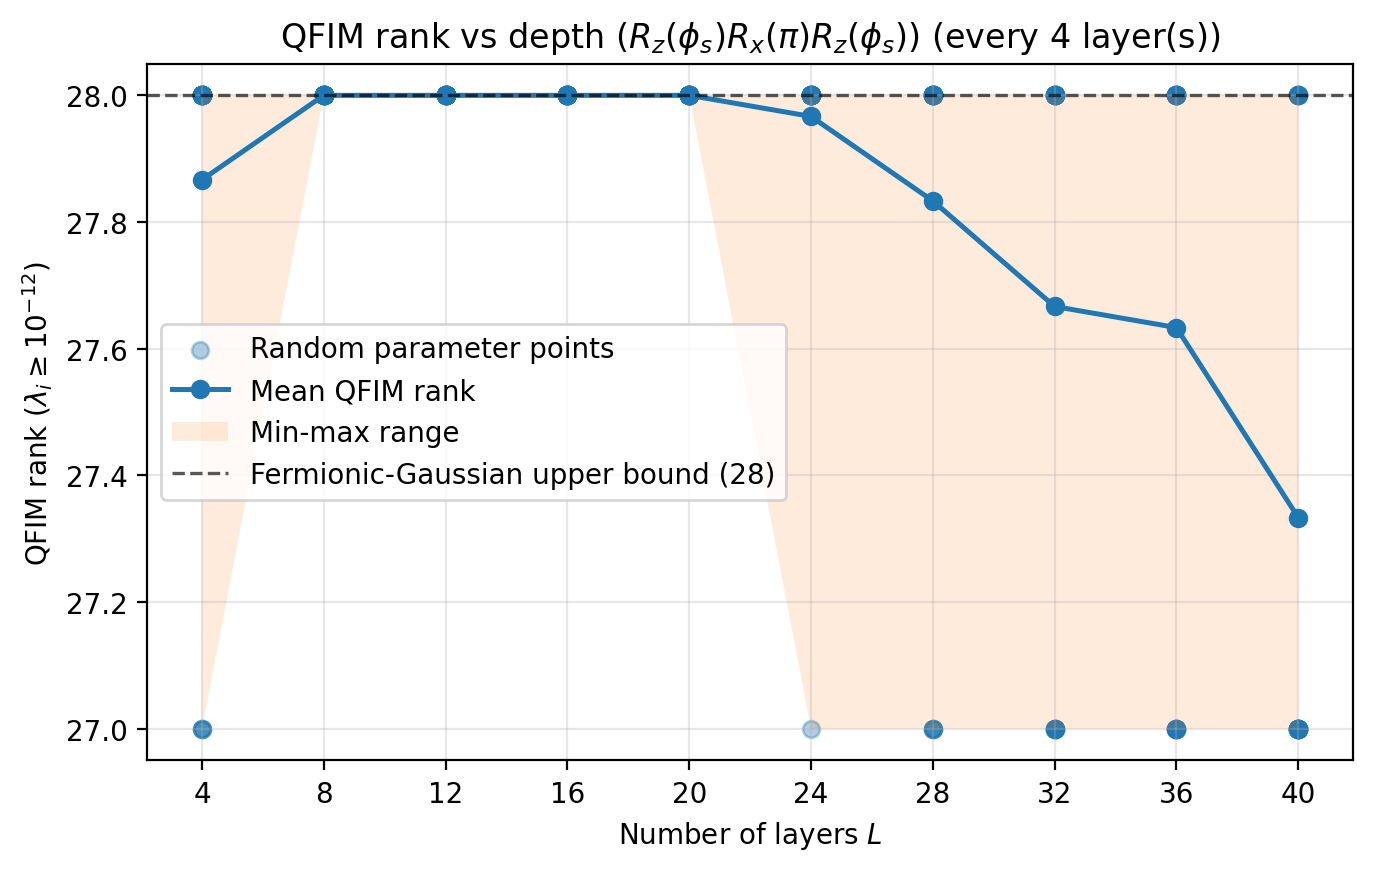

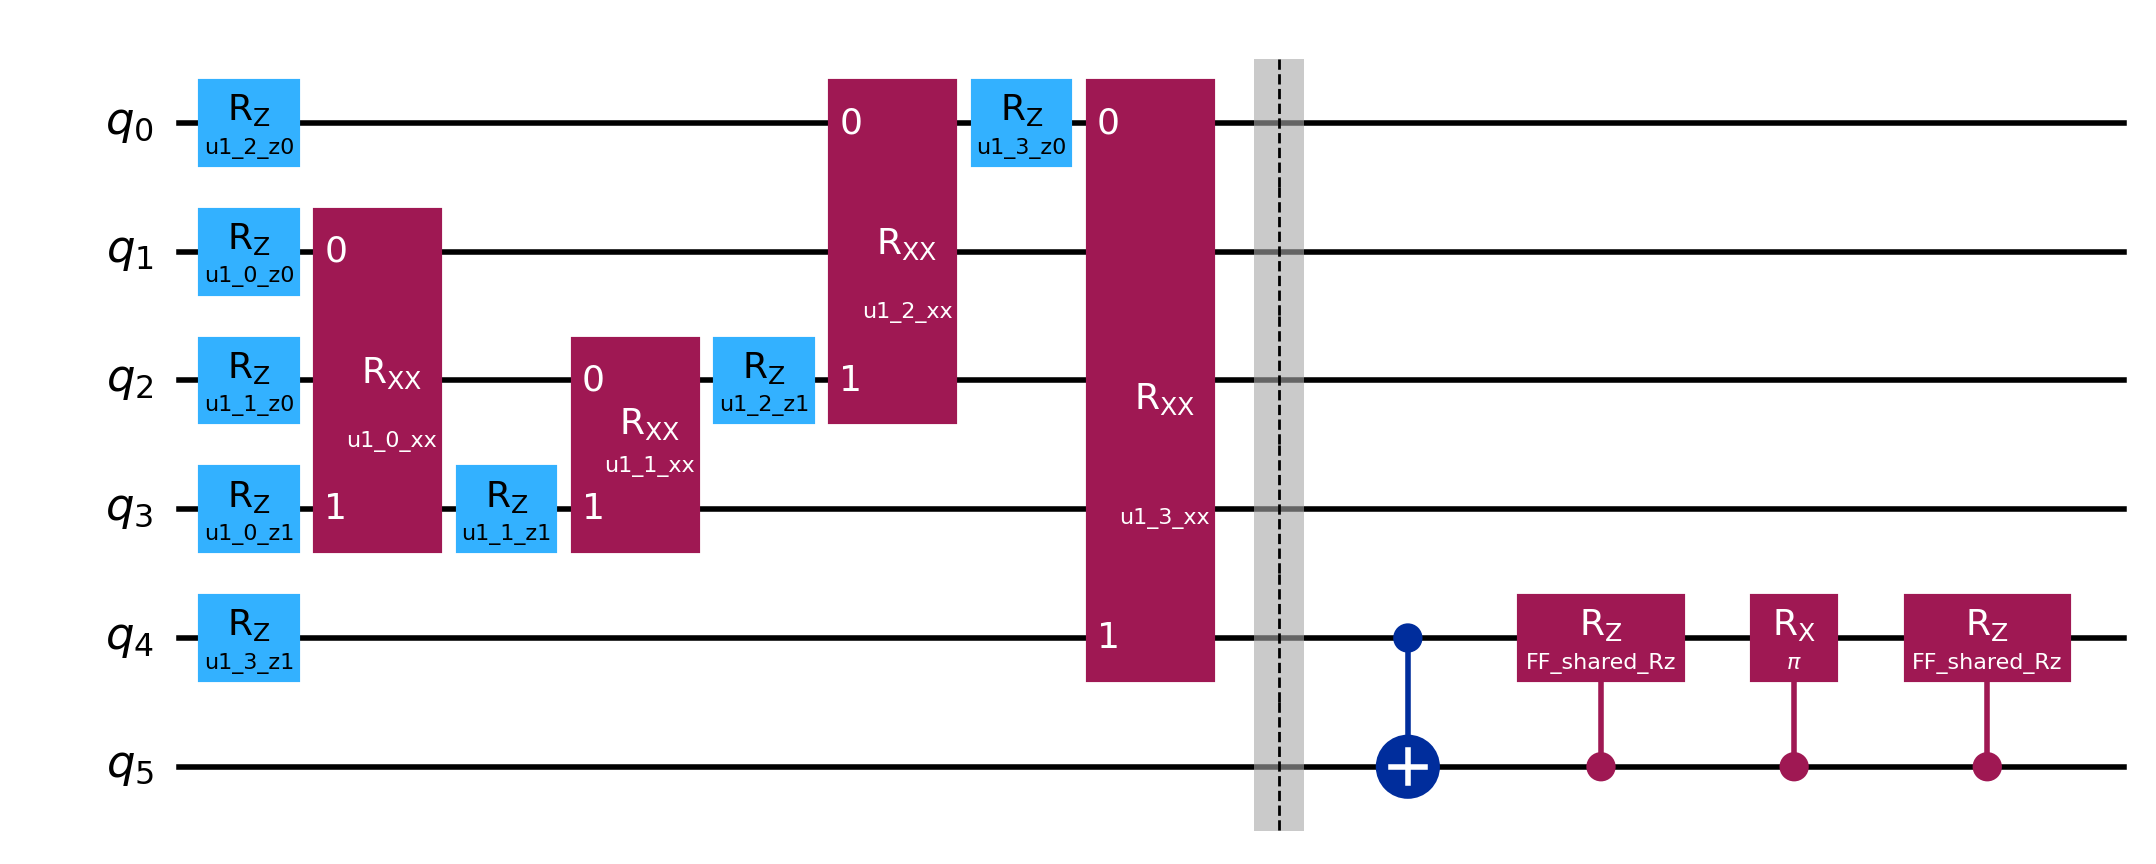

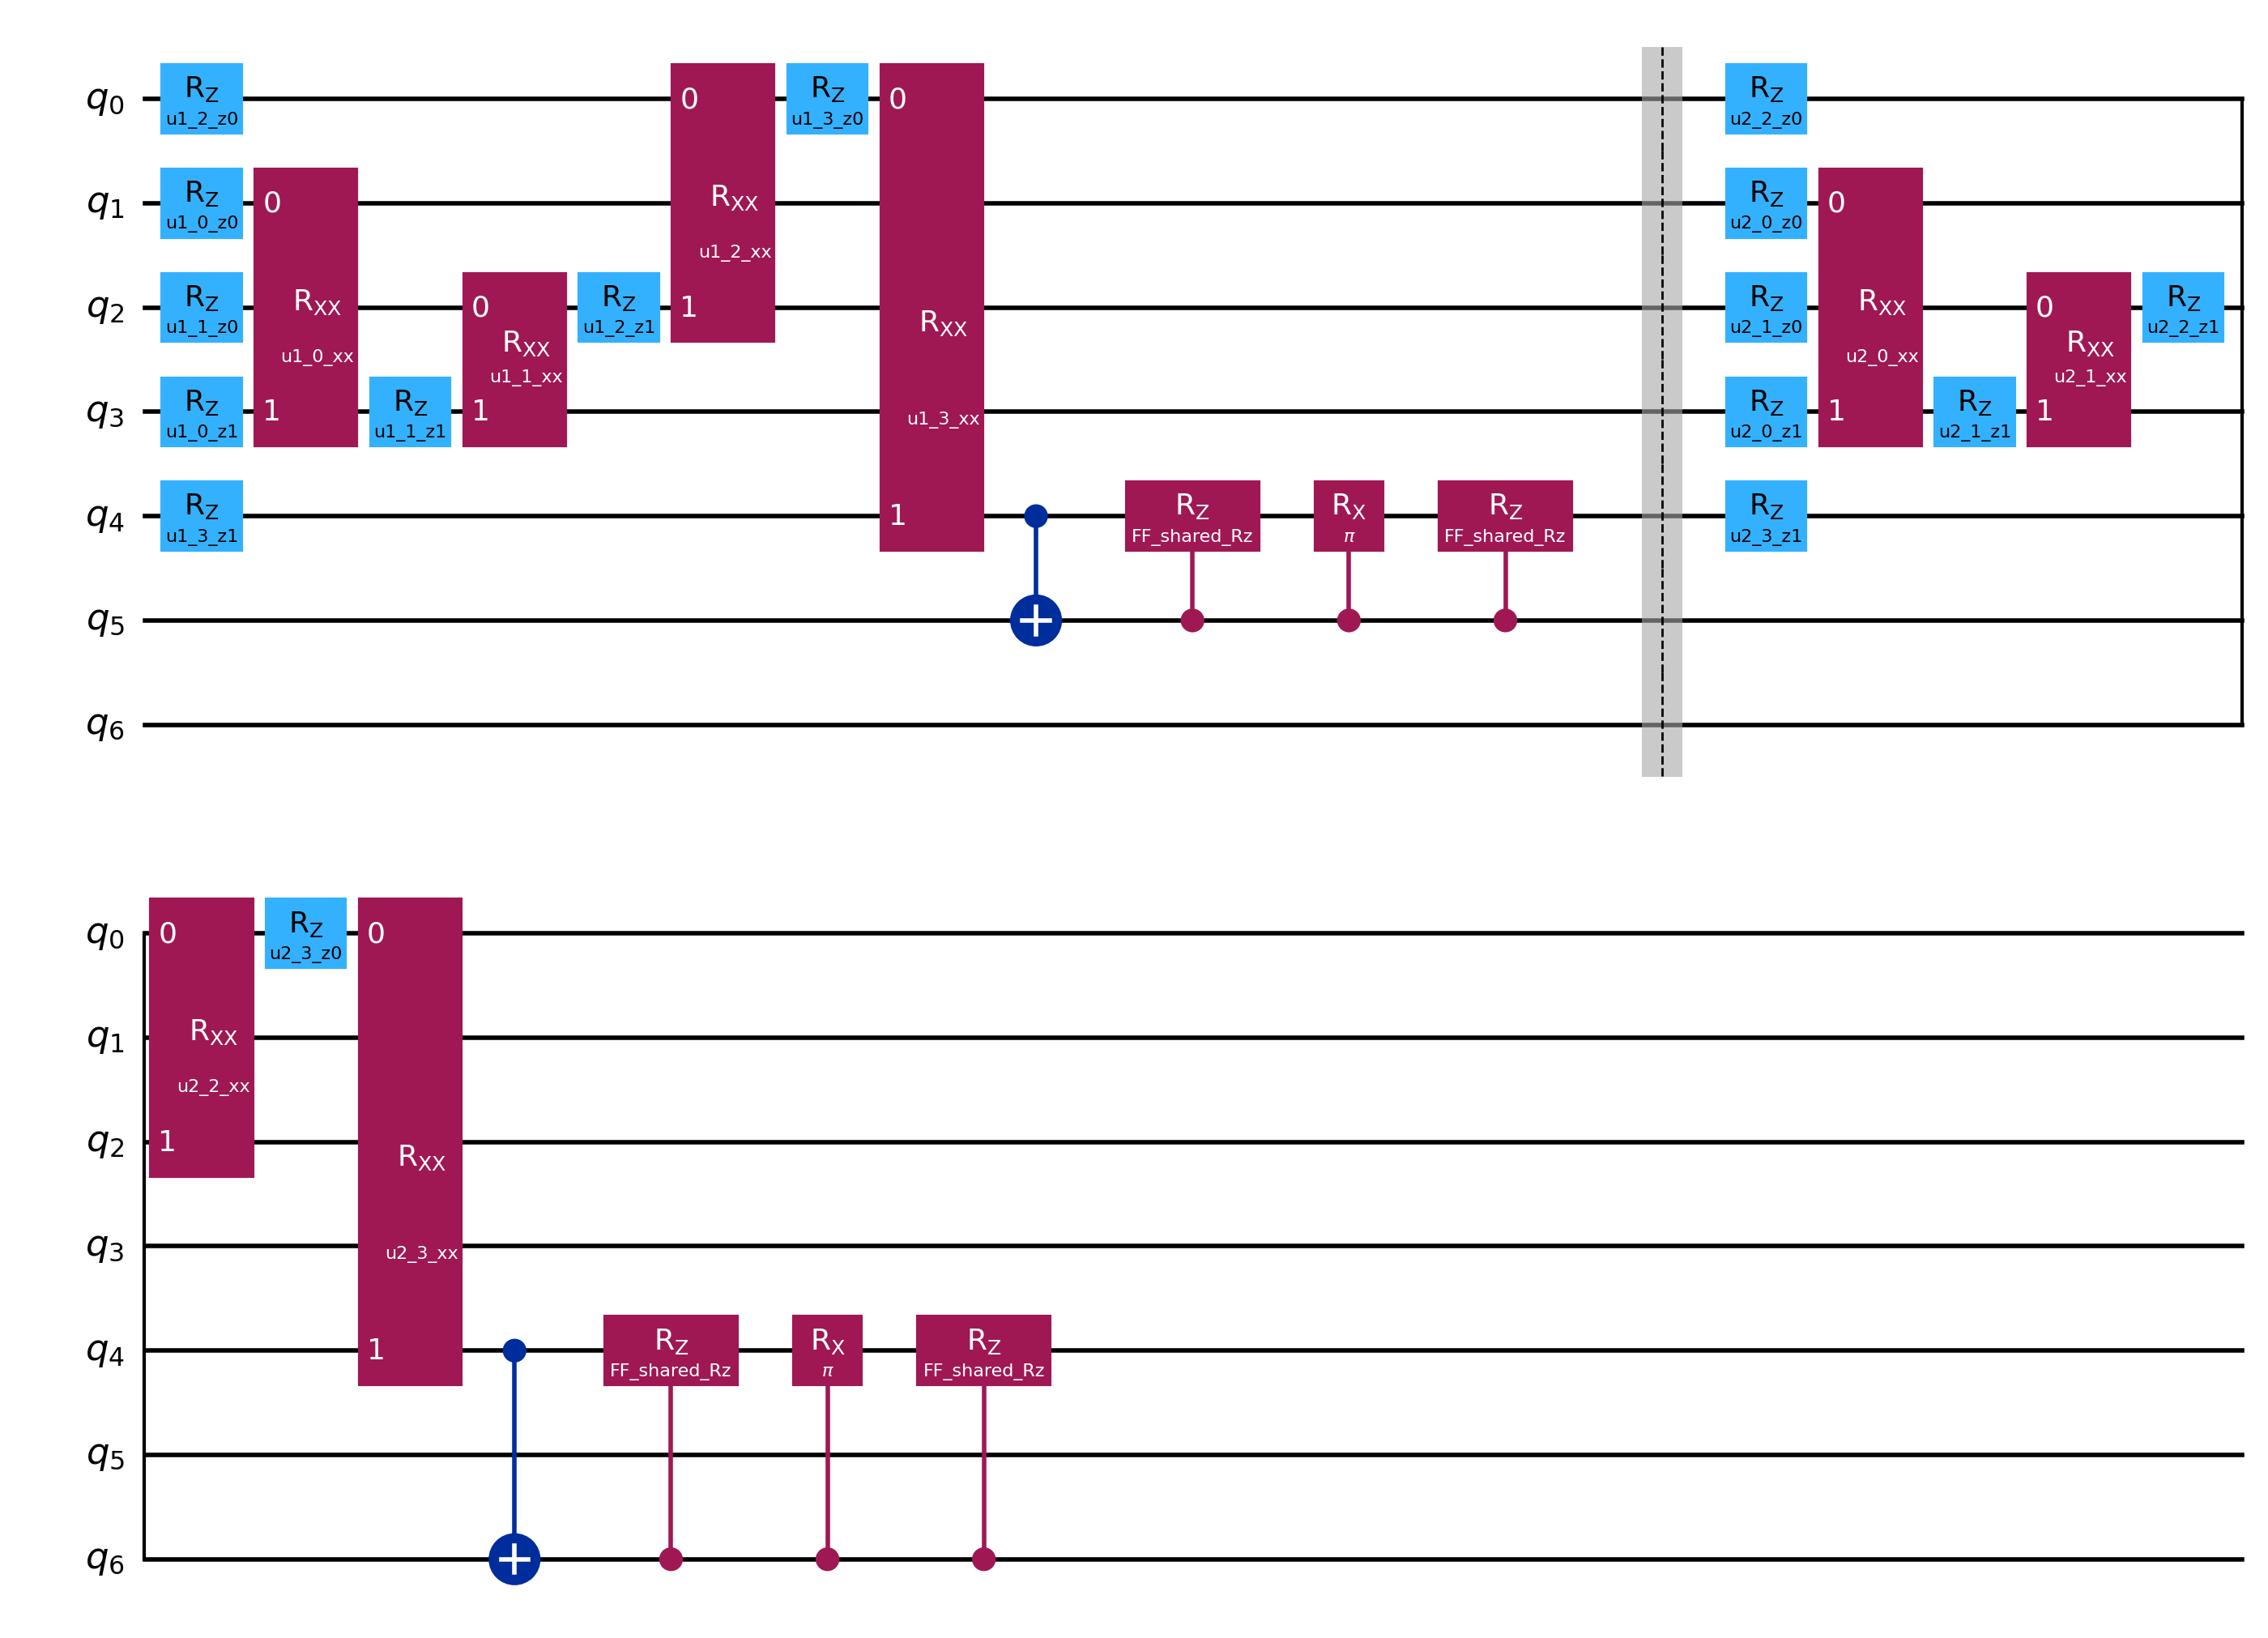

Trainable feed-forward parameters: ('FF_shared_Rz',)
Feed-forward operator: CRz(phi_shared)-CRx(pi)-CRz(phi_shared), exactly equal to CRx(pi). Fixed Rx angle=3.141592653589793 rad
Shared Rz is an exact QFIM null direction: True
QFIM evaluated every 4 layer(s): (4, 8, 12, 16, 20, 24, 28, 32, 36, 40)
Saved results and figures to: C:\Users\hkent\OneDrive\デスクトップ\DynamicParametrizedQuantumCircuit\src\dpqc\outputs\dpqc_shared_rz_fixed_rx_pi


In [2]:
from IPython.display import Image as IPythonImage, display

OUTPUT_DIR = Path("outputs") / "dpqc_shared_rz_fixed_rx_pi"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

QFIM_MAX_LAYER = 40
QFIM_LAYER_INTERVAL = 4  # X: e.g. 5 evaluates L=5, 10, 15

if QFIM_MAX_LAYER < 1:
    raise ValueError("QFIM_MAX_LAYER must be >= 1.")

if not 1 <= QFIM_LAYER_INTERVAL <= QFIM_MAX_LAYER:
    raise ValueError(
        "QFIM_LAYER_INTERVAL must be between 1 and QFIM_MAX_LAYER."
    )

LAYER_VALUES = tuple(
    range(
        QFIM_LAYER_INTERVAL,
        QFIM_MAX_LAYER + 1,
        QFIM_LAYER_INTERVAL,
    )
)
NUM_RANDOM_POINTS = 30
SAMPLE_BATCH_SIZE = 4
JVP_CHUNK = None  # all tangent directions; set 16 if memory is limited
RANDOM_SEED = 0
CIRCUIT_DRAW_LAYERS = 2
REUSE_EXACT_RX_PI_ONLY_RESULTS = True
RX_PI_ONLY_RESULTS_PATH = (
    Path("outputs")
    / "dpqc_fixed_rx_pi_only"
    / "qfim_rank_results.csv"
)

def load_equivalent_rx_pi_only_results(path):
    """Lift exact Rx(pi)-only results by one zero-QFIM direction."""
    source = pd.read_csv(path)
    expected_rows = len(LAYER_VALUES) * NUM_RANDOM_POINTS
    layer_counts = source.groupby("layer").size()
    expected_counts = pd.Series(
        NUM_RANDOM_POINTS,
        index=pd.Index(LAYER_VALUES, name="layer"),
    )
    valid = (
        len(source) == expected_rows
        and layer_counts.equals(expected_counts)
        and np.array_equal(
            source["num_unitary_parameters"].to_numpy(),
            (12 * source["layer"]).to_numpy(),
        )
        and np.allclose(source["fixed_ff_rx_angle"], np.pi)
        and np.all(
            source["num_trainable_feed_forward_parameters"] == 0
        )
    )
    if not valid:
        raise ValueError(
            "Rx(pi)-only cache is incompatible with this execution grid."
        )

    result = source.copy()
    result["num_parameters"] = (
        result["num_unitary_parameters"] + 1
    )
    result["num_trainable_feed_forward_parameters"] = 1
    result["trainable_feed_forward_parameter_names"] = str(
        TRAINABLE_FEED_FORWARD_PARAMETER_NAMES
    )
    result["feed_forward_operator"] = (
        "CRz(phi_shared)-CRx(pi)-CRz(phi_shared)"
    )
    result["shared_rz_exactly_redundant"] = True
    result["min_eigenvalue"] = np.minimum(
        result["min_eigenvalue"],
        0.0,
    )
    return result[
        [
            "layer",
            "sample",
            "seed",
            "num_parameters",
            "num_unitary_parameters",
            "num_trainable_feed_forward_parameters",
            "trainable_feed_forward_parameter_names",
            "fixed_ff_rx_angle",
            "feed_forward_operator",
            "shared_rz_exactly_redundant",
            "qfim_rank",
            "min_eigenvalue",
            "max_eigenvalue",
        ]
    ]

if REUSE_EXACT_RX_PI_ONLY_RESULTS and RX_PI_ONLY_RESULTS_PATH.exists():
    qfim_results = load_equivalent_rx_pi_only_results(
        RX_PI_ONLY_RESULTS_PATH
    )
    print(
        "Reused exact Rx(pi)-only QFIM results; "
        "the shared Rz adds one analytic zero direction."
    )
else:
    qfim_results = sample_qfim_ranks_vs_layers(
        LAYER_VALUES,
        num_random_points=NUM_RANDOM_POINTS,
        seed=RANDOM_SEED,
        sample_batch_size=SAMPLE_BATCH_SIZE,
        jvp_chunk=JVP_CHUNK,
        show_progress=True,
    )
qfim_results.to_csv(OUTPUT_DIR / "qfim_rank_results.csv", index=False)
display(qfim_results)

rank_fig, rank_ax = plot_qfim_rank_vs_layers(
    qfim_results,
    title=(
        r"QFIM rank vs depth ($R_z(\phi_s)R_x(\pi)R_z(\phi_s)$) "
        f"(every {QFIM_LAYER_INTERVAL} layer(s))"
    ),
)
rank_ax.axhline(
    FERMIONIC_GAUSSIAN_QFIM_RANK_BOUND,
    color="black",
    linestyle="--",
    linewidth=1.2,
    alpha=0.65,
    label="Fermionic-Gaussian upper bound (28)",
)
rank_ax.legend()
rank_fig.tight_layout()
RANK_PLOT_PATH = OUTPUT_DIR / "qfim_rank_vs_layers.png"
save_figure(
    rank_fig,
    RANK_PLOT_PATH,
    dpi=200,
    bbox_inches="tight",
)
display(IPythonImage(filename=str(RANK_PLOT_PATH)))
plt.close(rank_fig)

SINGLE_LAYER_PATH = (
    OUTPUT_DIR / "single_layer_shared_rz_fixed_rx_pi.png"
)
single_layer_fig = draw_single_layer(
    1,
    output_path=SINGLE_LAYER_PATH,
)
display(IPythonImage(filename=str(SINGLE_LAYER_PATH)))
plt.close(single_layer_fig)

FULL_CIRCUIT_PATH = (
    OUTPUT_DIR
    / f"full_dpqc_L{CIRCUIT_DRAW_LAYERS}_shared_rz_fixed_rx_pi.png"
)
full_circuit_fig = draw_full_dpqc(
    CIRCUIT_DRAW_LAYERS,
    fold=20,
    output_path=FULL_CIRCUIT_PATH,
)
display(IPythonImage(filename=str(FULL_CIRCUIT_PATH)))
plt.close(full_circuit_fig)

print(
    "Trainable feed-forward parameters: "
    f"{TRAINABLE_FEED_FORWARD_PARAMETER_NAMES}"
)
print(
    "Feed-forward operator: CRz(phi_shared)-CRx(pi)-"
    "CRz(phi_shared), exactly equal to CRx(pi). "
    f"Fixed Rx angle={FIXED_FF_RX_ANGLE} rad"
)
print(
    "Shared Rz is an exact QFIM null direction: "
    f"{SHARED_RZ_EXACTLY_REDUNDANT}"
)
print(
    f"QFIM evaluated every {QFIM_LAYER_INTERVAL} layer(s): "
    f"{LAYER_VALUES}"
)
print(f"Saved results and figures to: {OUTPUT_DIR.resolve()}")